# Triplets pre-processing pipeline

This notebook is used for normalization on triplets produced by the triplets extraction pipeline.

Pre-processing configuration:

In [177]:
filepath = "./artifacts/raw_triplets/"

triplet_files = [# Category_name, file_name in each category
    ("core_clinical", ["core_clinical_numsamples2000_start0.csv"]),
    ("basic_biology", ["basic_biology_numsamples2000_start0.csv"]),
    ("pharmacology", ["pharmacology_numsamples2000_start0.csv"]),
    ("psychiatry", ["psychiatry_numsamples2000_start0.csv"])
]

output_path = "./artifacts/graph_triplets"

# minimum length threshold for strings to be considered valid
k = 2  

# Minimum occurence of entities
min_entity_support = 2

# Minimum occurence of relation types
min_edge_support = 1 # Set to 1 as the number of relation types is small (73, see below)

In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

Load and perform basic cleaning on data:

In [ ]:
# Read triplets from files and perform basic normalization

CLEAN_REGEX = r"[^a-z0-9\s\-\.\+]+"  # allow letters, numbers, space, -, ., +

def normalize_text(col: pd.Series):
    return (
        col.astype(str)
           .str.replace('_', ' ', regex=False)
           .str.strip()
           .str.lower()
           # Remove unwanted chars but KEEP spaces
           .str.replace(CLEAN_REGEX, " ", regex=True)
           # Normalize hyphens (keep them, but spaced)
           .str.replace(r"\s*-\s*", "-", regex=True)
           # Collapse multiple spaces
           .str.replace(r"\s+", " ", regex=True)
           # Remove leading/trailing punctuation
           .str.strip(" .-+")
    )

clean_dfs = dict()

# Read and process separated triplets file 
for ctg, files in triplet_files:
    ctg_df = pd.concat([
        pd.read_csv(
            os.path.join(filepath, filename),
            on_bad_lines='skip',
            encoding='utf-8',
            encoding_errors='ignore',
            names=['Subject', 'Predicate', 'Object']
        )
        for filename in files
    ])        

    # Normalize texts
    ctg_df = ctg_df.assign(
            Subject=lambda df: normalize_text(df['Subject']),
            Predicate=lambda df: normalize_text(df['Predicate']),
            Object=lambda df: normalize_text(df['Object'])
        ).replace("", pd.NA)\
        .dropna(subset=['Subject', 'Predicate', 'Object']) # Fill empty fields with NA and remove malformed rows
    
    # Remove rows whose fields do not satisfy minimum length threshold
    ctg_df = ctg_df.loc[lambda df: (
            df['Subject'].str.len().ge(k) &
            df['Predicate'].str.len().ge(k) &
            df['Object'].str.len().ge(k)
        )]
    
    # Drop obvious garbage rows and remove duplications
    ctg_df = ctg_df.loc[lambda df: (
            ~df['Subject'].str.match(r"^(and|or|of|in|on|at)$") &
            ~df['Object'].str.match(r"^(and|or|of|in|on|at)$")
        )]\
        .drop_duplicates(subset=['Subject', 'Predicate', 'Object'])\
        .reset_index(drop=True)

    # Remove self-loops (Subject == Object)
    ctg_df = ctg_df[ctg_df['Subject'] != ctg_df['Object']]
    
    # Remove rows containing "figure" in any column
    ctg_df = ctg_df[
        ~ctg_df['Subject'].str.contains('figure', case=False, na=False) &
        ~ctg_df['Predicate'].str.contains('figure', case=False, na=False) &
        ~ctg_df['Object'].str.contains('figure', case=False, na=False)
    ]

    clean_dfs[ctg] = ctg_df

In [ ]:
for ctg, df in clean_dfs.items():
    entity_count = pd.concat([df['Subject'], df['Object']]).unique().shape[0]
    print(f"Category: {ctg} Number of triplets: {df.shape[0]} Number of entites: {entity_count}")

Category: core_clinical Number of triplets: 16563 Number of entites: 7875
Category: basic_biology Number of triplets: 8668 Number of entites: 5805
Category: pharmacology Number of triplets: 9555 Number of entites: 7412
Category: psychiatry Number of triplets: 8762 Number of entites: 6548


Concatenate DataFrames into a single unit and perform global de-duplication:

In [181]:
# Concatenate all dataframes and perform global de-duplication
large_df = pd.concat(list(clean_dfs.values()))

# Perform global de-duplication
large_df = large_df.drop_duplicates(
    subset=['Subject', 'Predicate', 'Object']
).reset_index(drop=True)

# Log the statistics
print("Entity count: ", pd.concat([
large_df['Subject'],
large_df['Object']
]).unique().shape)

print("Relation count: ", large_df['Predicate'].unique().shape)

large_df

Entity count:  (24647,)
Relation count:  (73,)


,Subject,Predicate,Object
0,anatomy,part of,medicine
1,clinical sign,facet of,disease
2,anatomy,practice by,physician
3,disease,study by,anatomy
4,structure,study by,macroscopic anatomy
...,...,...,...
43084,sexual sadism disorder,instance of,comorbiditie
43085,sub stance use disorder,instance of,comorbid
43086,sexual interest in child,instance of,paraphilia
43087,pedophilic sexual orientation,different from,pedophilic disorder


Plot the frequency of each occurence count:

In [182]:
def plot_freq_of_freq(data: pd.DataFrame, ax: plt.Axes, title: str):
    """
    Plot frequency-of-frequency bar chart
    """
    
    # Count the occurence of each entity
    entity_counts = data[['Subject', 'Object']].stack().value_counts()

    # Frequency of each occurence count
    freq_of_freq = entity_counts.value_counts().sort_index()

    # Make x-axis values
    full_index = np.arange(1, entity_counts.max() + 1) 
    freq_of_freq = freq_of_freq.reindex(full_index, fill_value=0)

    # Plot 
    ax.bar(freq_of_freq.index, freq_of_freq.values)
    ax.set_yscale('log')

    ax.set_xlabel("Entity occurrence count (x)")
    ax.set_ylabel("Number of nodes with count x")
    ax.set_title(title)

    return ax

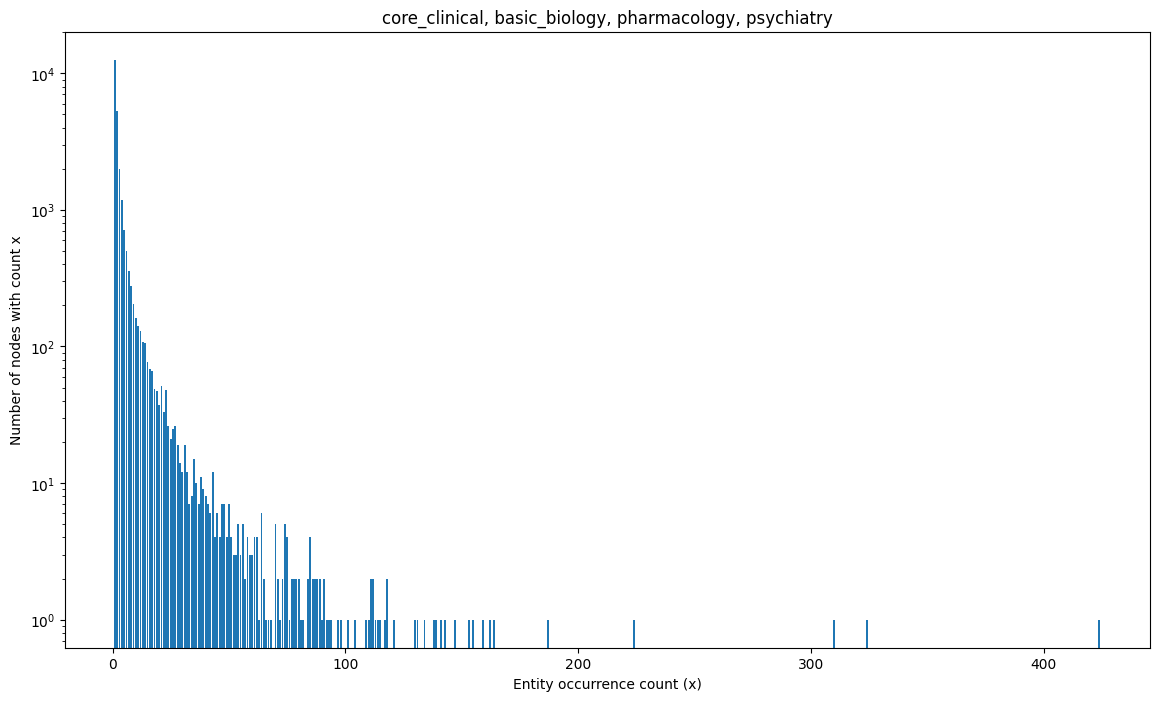

In [183]:
# Plot freq-of-freq of normalized data

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(14, 8), )

plot_freq_of_freq(large_df, axs, ", ".join(clean_dfs.keys()))

plt.show()

Perform k-core pruning to remove rare entities, thus stabilizing the data:

In [184]:
def prune_entities(data: pd.DataFrame, min_count=2):
    """
    Perform k-core pruning to remove rare entities
    """
    
    df = data.copy()

    while True:
        # Collect all entities in triplets
        counts = df[['Subject', 'Object']].stack().value_counts()

        # Get entities with >= number of occurences
        valid_entities = counts[counts >= min_count].index

        # Make mask
        new_df = df[
            df['Subject'].isin(valid_entities) &
            df['Object'].isin(valid_entities)
        ]

        # Stop when the dataframe is stable
        if len(new_df) == len(df):
            break
        df = new_df

    return df

pruned_df = prune_entities(large_df, min_count=min_entity_support)

Remove rare edges can help reduce the downstream R-GCN's complexity:

In [185]:
# Count occurence per-relation label
rel_counts = pruned_df["Predicate"].value_counts()

# Remove insufficient relations
pruned_df = pruned_df[
pruned_df["Predicate"].isin(rel_counts[rel_counts >= min_edge_support].index)
]

# Log the statistics
print("Entity count: ", pd.concat([
pruned_df['Subject'],
pruned_df['Object']
]).unique().shape)

print("Relation count: ", pruned_df['Predicate'].unique().shape)

pruned_df

Entity count:  (10521,)
Relation count:  (55,)


,Subject,Predicate,Object
0,anatomy,part of,medicine
1,clinical sign,facet of,disease
2,anatomy,practice by,physician
3,disease,study by,anatomy
4,structure,study by,macroscopic anatomy
...,...,...,...
43081,f65.4,have,diagnostic criterion 302.2
43082,comorbid,subclass of,disorder
43083,diagnostic criterion 302.2,part of,f65.4
43084,sexual sadism disorder,instance of,comorbiditie


After-pruning illustration:

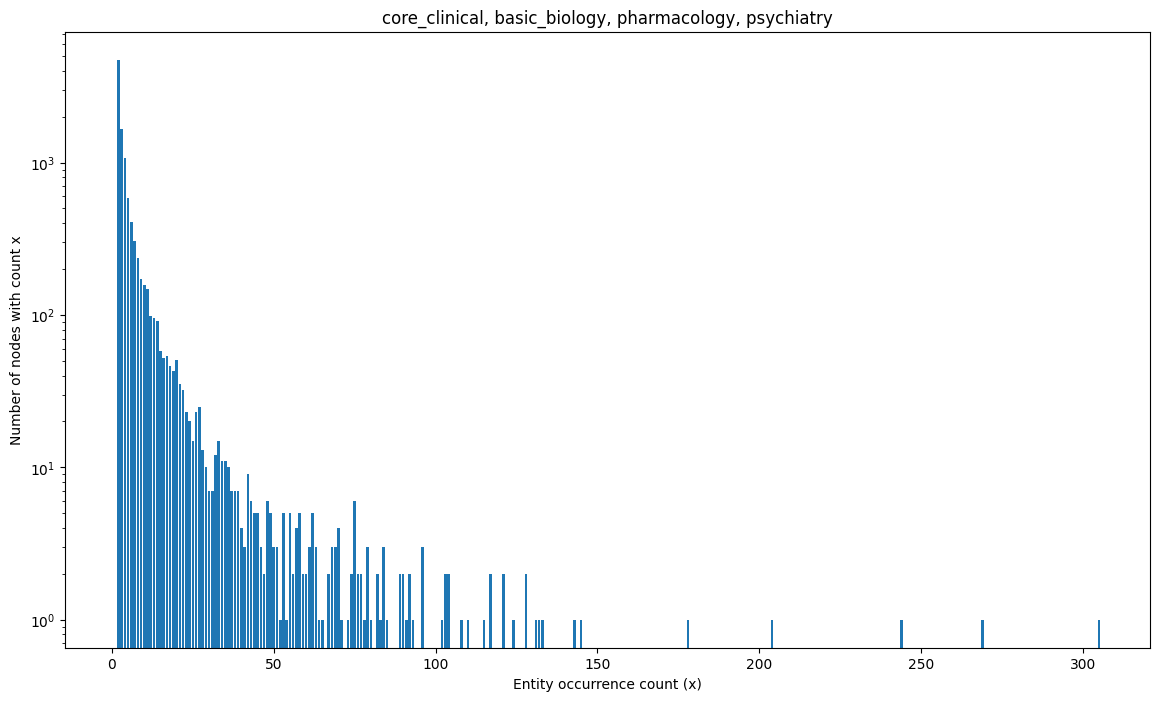

In [186]:
# Plot freq-of-freq of pruned data

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(14, 8), )

plot_freq_of_freq(pruned_df, axs, ", ".join(clean_dfs.keys()))

plt.show()

Connectivity illustration:

Seed nodes: 1
Extended nodes (1-hop): 17


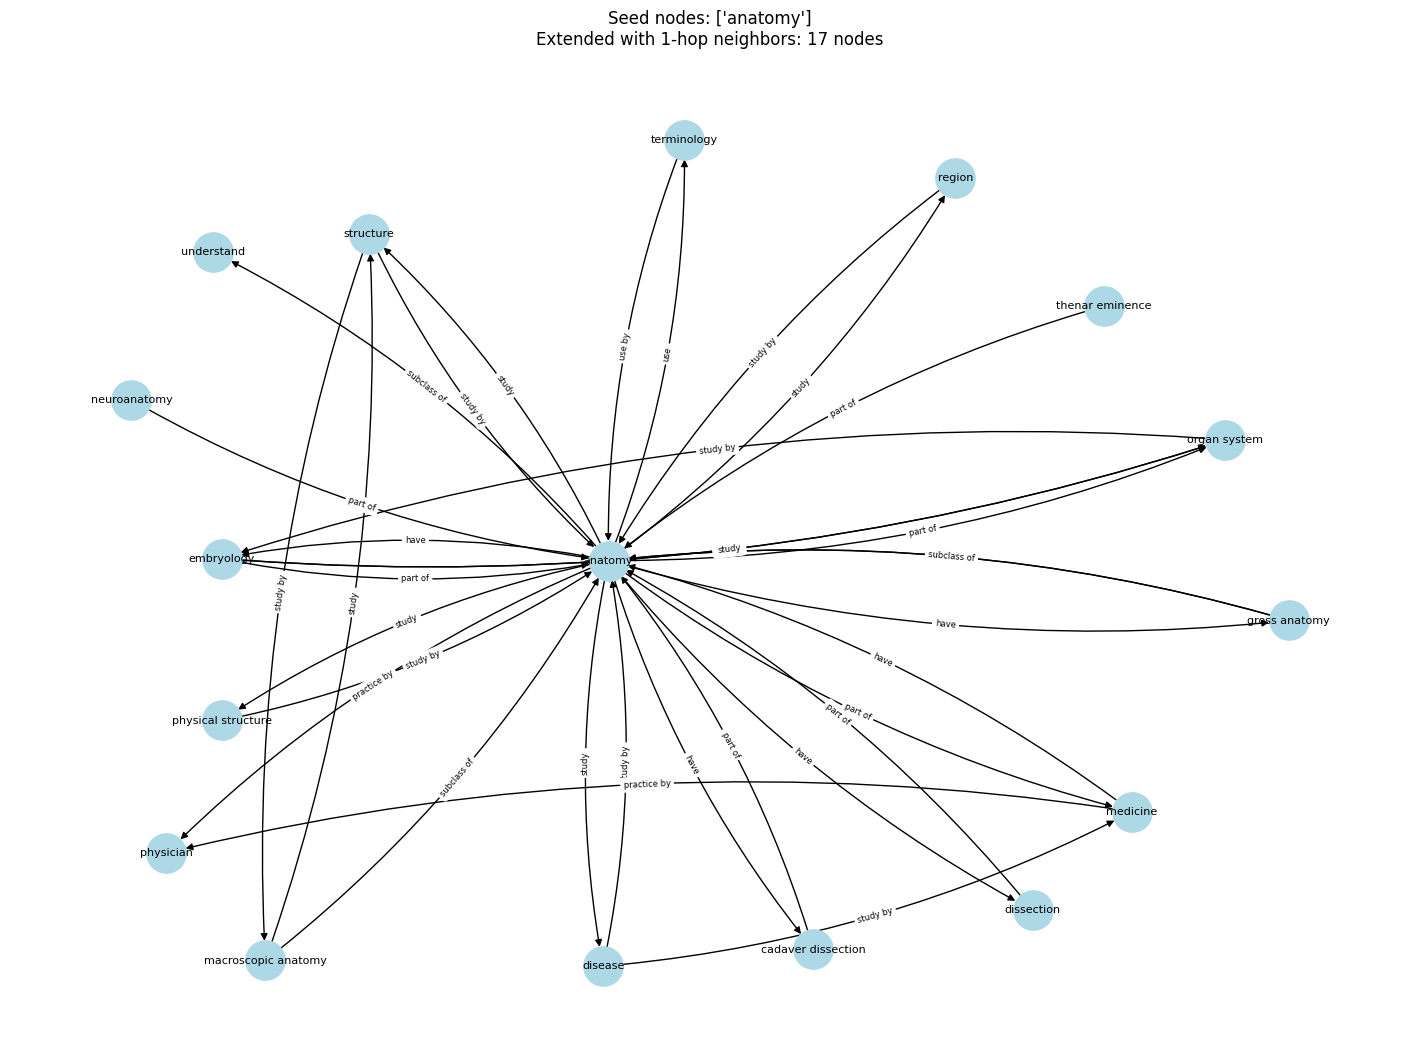

In [187]:
import networkx as nx
import matplotlib.pyplot as plt

# Seed nodes to start from
seed_nodes = ["anatomy"]

# Extend to include neighbors (1-hop from seed nodes)
def get_neighbors(df: pd.DataFrame, seeds: list, n_hops: int = 1):
    """Extend seed nodes to include their neighbors."""
    all_nodes = set(seeds)
    
    for _ in range(n_hops):
        # Find all nodes connected to current nodes
        connected_subj = df[df['Object'].isin(all_nodes)]['Subject'].unique()
        connected_obj = df[df['Subject'].isin(all_nodes)]['Object'].unique()
        all_nodes.update(connected_subj)
        all_nodes.update(connected_obj)
    
    return all_nodes

# Get extended nodes
extended_nodes = get_neighbors(pruned_df, seed_nodes, n_hops=1)
print(f"Seed nodes: {len(seed_nodes)}")
print(f"Extended nodes (1-hop): {len(extended_nodes)}")

# Create subgraph with extended nodes
df_dict = pruned_df.to_dict()
triplets = [
    (s, r, o) for s, r, o in zip(df_dict['Subject'].values(), df_dict['Predicate'].values(), df_dict['Object'].values())
]

G = nx.MultiDiGraph()
for head, rel, tail in triplets:
    G.add_edge(head, tail, label=rel)

G_sub = G.subgraph(extended_nodes)

# Layout
pos = nx.spring_layout(G_sub, k=2, iterations=50)

# Draw
plt.figure(figsize=(14, 10))
nx.draw(G_sub, pos, with_labels=True, node_size=800, node_color="lightblue", 
        font_size=8, connectionstyle='arc3, rad=0.1', arrows=True, arrowsize=10)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G_sub, 'label')
nx.draw_networkx_edge_labels(G_sub, pos, edge_labels=edge_labels, 
                              font_size=6, connectionstyle='arc3, rad=0.1')

plt.title(f"Seed nodes: {seed_nodes}\nExtended with 1-hop neighbors: {len(extended_nodes)} nodes")
plt.show()

Output to a single file:

In [188]:
os.makedirs(output_path, exist_ok=True)
pruned_df.to_csv(f"{output_path}/graph_edges.csv", header=False, index=False)